In [1]:
import yfinance as yf

# Stock symbol for Reliance Industries Ltd.
stock_symbol = 'RELIANCE.NS'

# Data collection for last 1 year
stock_data = yf.download(stock_symbol, start="2023-01-01", end="2024-01-01")

# Display the data
print(stock_data.head())


[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open      Volume
Ticker      RELIANCE.NS  RELIANCE.NS  RELIANCE.NS  RELIANCE.NS RELIANCE.NS
Date                                                                      
2023-01-02  1172.422974  1173.833955  1159.815273  1160.634533     5316175
2023-01-03  1163.843384  1171.103078  1159.633312  1167.484608     7658932
2023-01-04  1146.319946  1165.663880  1144.248981  1163.820454     9264891
2023-01-05  1144.271851  1154.444524  1139.697597  1148.573058    13637099
2023-01-06  1154.671997  1159.701449  1146.206227  1150.006728     6349597


In [2]:
stock_data.head()

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2023-01-02,1172.422974,1173.833955,1159.815273,1160.634533,5316175
2023-01-03,1163.843384,1171.103078,1159.633312,1167.484608,7658932
2023-01-04,1146.319946,1165.663880,1144.248981,1163.820454,9264891
2023-01-05,1144.271851,1154.444524,1139.697597,1148.573058,13637099
2023-01-06,1154.671997,1159.701449,1146.206227,1150.006728,6349597


In [3]:
stock_data.describe

<bound method NDFrame.describe of Price             Close         High          Low         Open      Volume
Ticker      RELIANCE.NS  RELIANCE.NS  RELIANCE.NS  RELIANCE.NS RELIANCE.NS
Date                                                                      
2023-01-02  1172.422974  1173.833955  1159.815273  1160.634533     5316175
2023-01-03  1163.843384  1171.103078  1159.633312  1167.484608     7658932
2023-01-04  1146.319946  1165.663880  1144.248981  1163.820454     9264891
2023-01-05  1144.271851  1154.444524  1139.697597  1148.573058    13637099
2023-01-06  1154.671997  1159.701449  1146.206227  1150.006728     6349597
...                 ...          ...          ...          ...         ...
2023-12-22  1273.848755  1281.720070  1265.207538  1271.142214    16541784
2023-12-26  1280.304810  1287.207745  1272.681682  1275.313779     7465664
2023-12-27  1284.675049  1291.155810  1277.846558  1282.266405     9204156
2023-12-28  1293.961792  1297.164951  1284.675069  1286.140066    

In [5]:
# Drop rows with missing values
stock_data = stock_data.dropna()

In [6]:
stock_data.head()

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2023-01-02,1172.422974,1173.833955,1159.815273,1160.634533,5316175
2023-01-03,1163.843384,1171.103078,1159.633312,1167.484608,7658932
2023-01-04,1146.319946,1165.663880,1144.248981,1163.820454,9264891
2023-01-05,1144.271851,1154.444524,1139.697597,1148.573058,13637099
2023-01-06,1154.671997,1159.701449,1146.206227,1150.006728,6349597


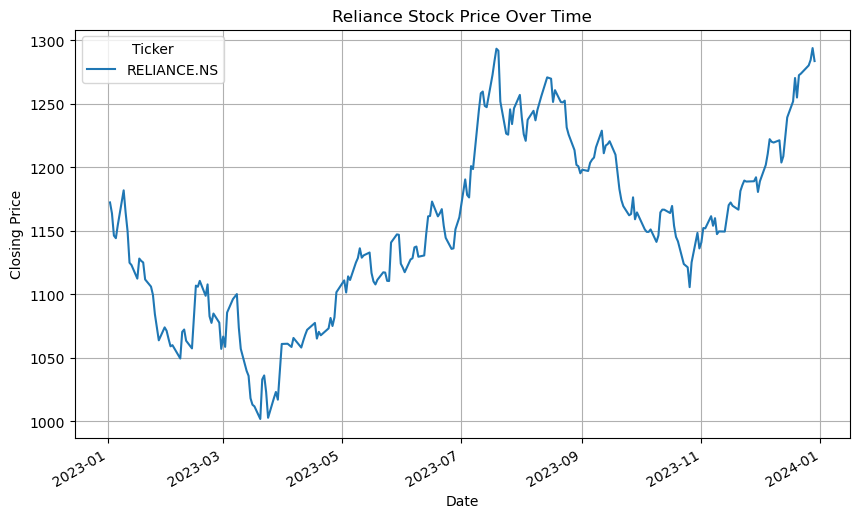

In [7]:
import matplotlib.pyplot as plt

# Plot Closing Price
stock_data['Close'].plot(figsize=(10,6))
plt.title('Reliance Stock Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True)
plt.show()


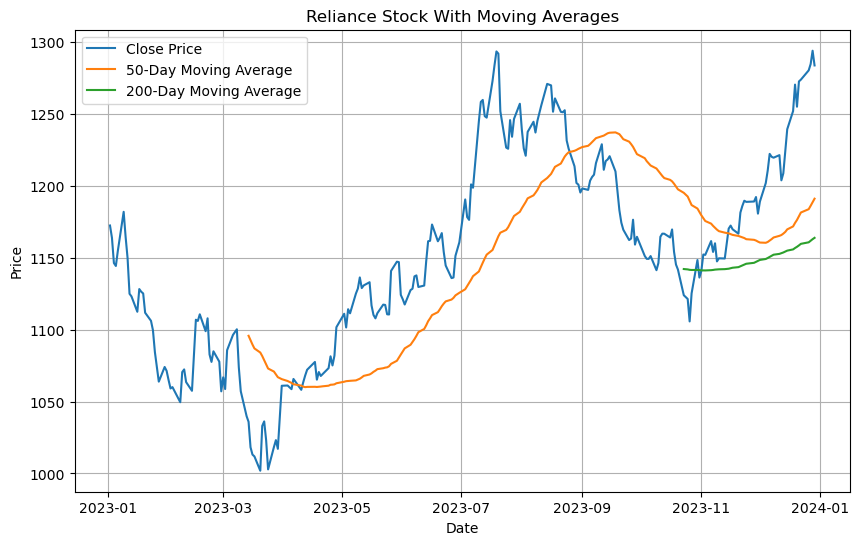

In [8]:
# SMA50 and SMA200 is a Simple Moving Average of 50 days and 200 days. Created This Feature for Prediction of future Value
stock_data['SMA50'] = stock_data['Close'].rolling(window=50).mean()
stock_data['SMA200'] = stock_data['Close'].rolling(window=200).mean()

plt.figure(figsize=(10,6))
plt.plot(stock_data['Close'], label='Close Price')
plt.plot(stock_data['SMA50'], label="50-Day Moving Average")
plt.plot(stock_data['SMA200'], label="200-Day Moving Average")
plt.legend()
plt.title('Reliance Stock With Moving Averages')
plt.xlabel('Date')
plt.ylabel("Price")
plt.grid(True)
plt.show()

In [9]:
stock_data.tail()

Price,Close,High,Low,Open,Volume,SMA50,SMA200
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,,
Date,,,,,,,
2023-12-22,1273.848755,1281.720070,1265.207538,1271.142214,16541784,1181.456987,1159.669706
2023-12-26,1280.304810,1287.207745,1272.681682,1275.313779,7465664,1183.771226,1160.737090
2023-12-27,1284.675049,1291.155810,1277.846558,1282.266405,9204156,1186.129666,1161.866948
2023-12-28,1293.961792,1297.164951,1284.675069,1286.140066,12302636,1188.674832,1162.908173
2023-12-29,1283.731323,1298.158085,1280.925483,1296.717943,10864584,1191.067532,1163.845222


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

# Remove NaN values from both features and target
features = stock_data[['SMA50', 'SMA200']].dropna()
target = stock_data['Close'].loc[features.index]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')


Mean Squared Error: 161.01467270623553
R-squared: 0.9491575645137904


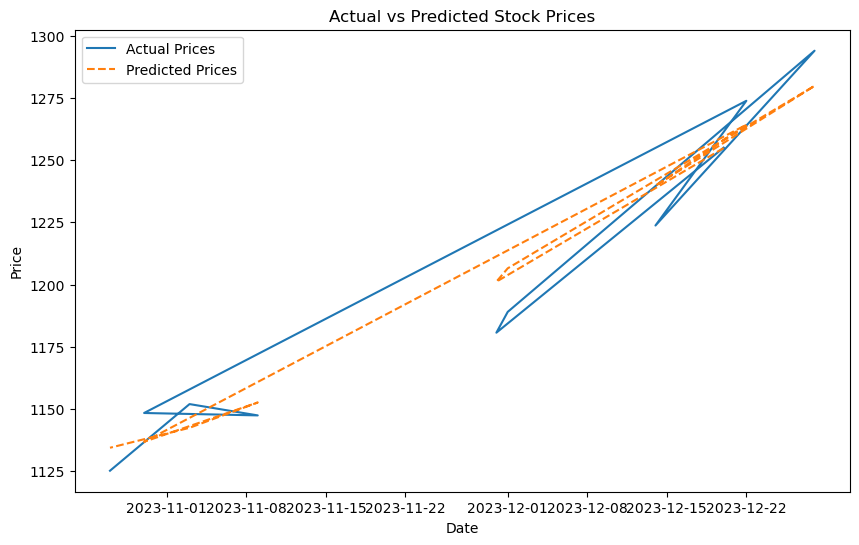

In [11]:
plt.figure(figsize=(10,6))
plt.plot(y_test.index, y_test, label='Actual Prices')
plt.plot(y_test.index, y_pred, label='Predicted Prices', linestyle='--')
plt.legend()
plt.title('Actual vs Predicted Stock Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

In [12]:
import pickle

# Save the trained model using pickle
with open('stock_price_predictor.pkl', 'wb') as file:
    pickle.dump(model, file)
